# Overview

As we know, in the ICR competition, the target variable is imbalanced with a ratio of 1:5. Various approaches have been suggested, including those discussed by Chris Deotte in this [discussion](https://www.kaggle.com/competitions/icr-identify-age-related-conditions/discussion/412507). However, I wanted to go deeper and explore more advanced techniques that could potentially improve our models' performance and compare them to simpler approaches. Luckily, I came across the imbalanced-learn framework - imblearn, which implements these methods.  For comparison basic model (median imputation -> catboost) is used with seeded KFold. 

To compare the approaches, I used a basic pipeline consisting of median imputation followed by the CatBoost classifier. To evaluate the models, I employed a seeded KFold cross-validation strategy.

# Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import TomekLinks

from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN

from catboost import CatBoostClassifier

from imblearn.pipeline import make_pipeline

from sklearn.model_selection import KFold

from copy import deepcopy

import matplotlib.pyplot as plt
import seaborn as sns

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Data Preparation

In [2]:
train = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv')

In [3]:
# SMOTE and TomekLinks (and combined algorithms that utilizean them)
# can only be applied to numerical features
train['EJ'] = (train['EJ'] == 'A').astype(int)

In [4]:
X = train.loc[:,'AB':'GL']
y = train.loc[:,'Class']

# Base Model

In [5]:
SEED = 1354

# Median for binary EJ is a most frequent value
imputer = SimpleImputer(strategy='median')

classifier = CatBoostClassifier(silent=True, random_seed=SEED)

base_model = make_pipeline(imputer, classifier)

# Cross Validation

In [6]:
# Competition's metric

def balanced_log_loss(y_true, y_pred):
    
    N_0 = np.sum(1 - y_true)
    N_1 = np.sum(y_true)
    
    w_0 = 1 / N_0
    w_1 = 1 / N_1
    
#     p_0 = np.clip(1-y_pred, 1e-15, 1 - 1e-15)
    p_1 = np.clip(y_pred, 1e-15, 1 - 1e-15)
    p_0 = 1-p_1

    log_loss_0 = -w_0 * np.sum((1-y_true) * np.log(p_0))
    log_loss_1 = -w_1 * np.sum(y_true * np.log(p_1))
      
    balanced_log_loss = (log_loss_0 + log_loss_1) / 2
            
    return balanced_log_loss

In [7]:
def perform_k_fold(model):
    ID_LIST = train.index

    oof = pd.Series(data=np.zeros(len(ID_LIST)), index=ID_LIST)

    models = []

    losses = []

    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    
    for train_index, valid_index in kf.split(X):
        
        x_train = X.iloc[train_index]
        y_train = y.iloc[train_index]

        model.fit(x_train, y_train)

        x_valid = X.iloc[valid_index]
        y_valid = y.iloc[valid_index]

        y_pred = model.predict_proba(x_valid)[:,1]

        oof.iloc[valid_index] = y_pred

        losses.append(balanced_log_loss(y_valid, y_pred))

    oof_loss = balanced_log_loss(y, oof)
    
    return losses, oof_loss

In [8]:
titles = ['No Sampling', 'Class Weight', 'Random DownSampling', 
          'Random UpSampling', 'SMOTE', 'Tomek Links',
          'SMOTE + Random Down-Sampling', 'SMOTEENN', 'SMOTE + Tomek Links']

# These steps will be added to our pipeline so that, up- or downsampling is performed inside the CV
# It's important, because we do not get over-optimistic metrics, due to copying same sample in both
# train and valid, or deleting hard cases from valid.
samplers = [
    None,
    None,
    RandomUnderSampler(sampling_strategy=1, random_state=SEED),
    RandomOverSampler(sampling_strategy=1, random_state=SEED),
    SMOTE(sampling_strategy=1, random_state=SEED), 
    TomekLinks(),
    [
        SMOTE(sampling_strategy=0.4, random_state=SEED),
        RandomUnderSampler(sampling_strategy=0.5, random_state=SEED)
    ],
    SMOTEENN(sampling_strategy=1, random_state=SEED),
    SMOTETomek(sampling_strategy=1, random_state=SEED), 
]

RandomOverSampler, SMOTE - UpSampling ⬆️

RandomUnderSampler, TomekLinks - DownSampling ⬇️

SMOTE + RandomUnderSampler, SMOTEENN, SMOTETomek - UpSampling⬆️ then downSampling⬇️

In [9]:
df = []

for i in range(len(titles)):
    title = titles[i]
    print(title)
    
    sampler = samplers[i]
    model = deepcopy(base_model)
    
    if title == 'Class Weight':
        model.set_params(catboostclassifier__auto_class_weights='Balanced')
        pass
    elif title == 'SMOTE + Random Down-Sampling':
        model.steps.insert(1, ('upsampler', sampler[0]))
        model.steps.insert(2, ('downsampler', sampler[1]))
    elif title != 'No Sampling':
        model.steps.insert(1, ('sampler', sampler))
    
    losses, oof_loss = perform_k_fold(model)
    
    df.append(pd.DataFrame([[title]*6, losses + [oof_loss], [False]*5+[True]]).transpose())
    
df = pd.concat(df)
df = df.rename(columns={0:'sampling_method', 1:'loss', 2:'is_oof'})

No Sampling
Class Weight
Random DownSampling
Random UpSampling
SMOTE
Tomek Links
SMOTE + Random Down-Sampling
SMOTEENN
SMOTE + Tomek Links


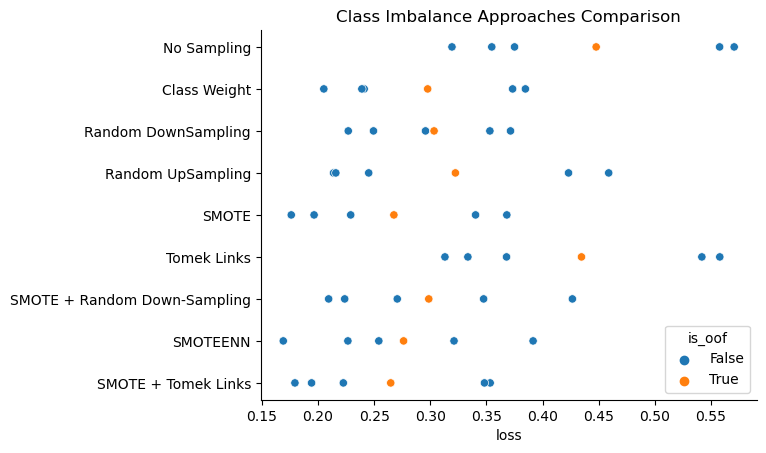

In [10]:
sns.scatterplot(data=df, y='sampling_method', x='loss', hue='is_oof')
plt.ylabel('')
plt.title('Class Imbalance Approaches Comparison')
sns.despine(top=True, right=True)

# Conclusion

From this graph I can tell that SMOTE + Tomek Links performs the best job (sligtly better than only SMOTE), It increases OOF-loss by about 0.2 relative to no sampling solution. But still there are a lot of space for the improvements:

1. There are still some methods that aren't covered, bacaus I added methods, which algorithm I understood (except for SMOTEENN :D)
2. I think better CV must be used, due to high STD between folds, but for now I didn't com up with a better one. In my case there are 3 folds that model finds quite easy and 2 difficult folds across all methods.
3. Fine-tuning the key hyperparameter in sampling, such as the sampling_strategy or ratio, is crucial, because I think perfect balance may not be an optimal solution. Maybe we should come to mild class imbalance (1:2), because generating/deleting a lot of point may lead to noisy data/loss of information.
4. I didn't it yet, but feature scaling is required, because SMOTE, TomekLinks, SMOTEENN in their core use euclidian distance.

Thank you for reading my notebook! Please share your thoughts and opinions, particularly regarding these three questions, in the comments section.